In [16]:
import xarray as xr
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# takes about 10 mins to run
dataset_list = []
for i in [1,2,3]:
    data = xr.open_dataset(f'..\\Data\\Snowpack_{i}.grib', engine='cfgrib')
    dataset_list.append(data)

data = xr.concat(dataset_list, dim='time')

C:\Users\max\AppData\Local\Temp\ipykernel_1052\4268426161.py:7: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  data = xr.concat(dataset_list, dim='time')


In [48]:
var = data['sd']
var = var.rio.write_crs("EPSG:4326")
shape = gpd.read_file('..\\Data\\watershed_mask.kml', driver='KML')
shape = shape.to_crs(var.rio.crs)
data_masked = var.rio.clip(shape.geometry, shape.crs, drop=True)
mean_snowcover = data_masked.mean(dim=['latitude', 'longitude'])

,time,mean_snowcover
96419,1990-01-01 00:00:00,0.107644
96420,1990-01-01 01:00:00,0.107644
96421,1990-01-01 02:00:00,0.107645
96422,1990-01-01 03:00:00,0.107795
96423,1990-01-01 04:00:00,0.107864


<Axes: xlabel='time'>

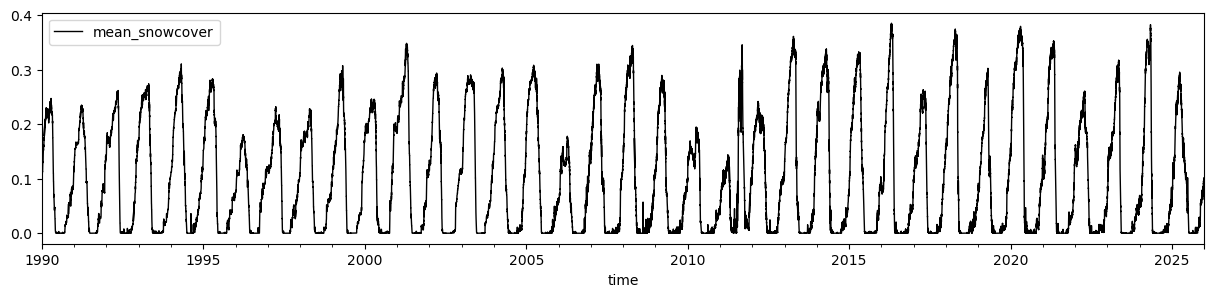

In [54]:
df = mean_snowcover.to_dataframe().reset_index()[['time', 'sd']]
df.rename(columns={'sd': 'mean_snowcover'}, inplace=True)
df.sort_values('time', inplace=True)
df.to_csv('..\\Data\\mean_snowcover_timeseries.csv', index=False)

display(df.head())
fig, ax = plt.subplots(figsize=(15, 3))
df.plot(x='time', y='mean_snowcover', ax=ax, lw=1, color='black')

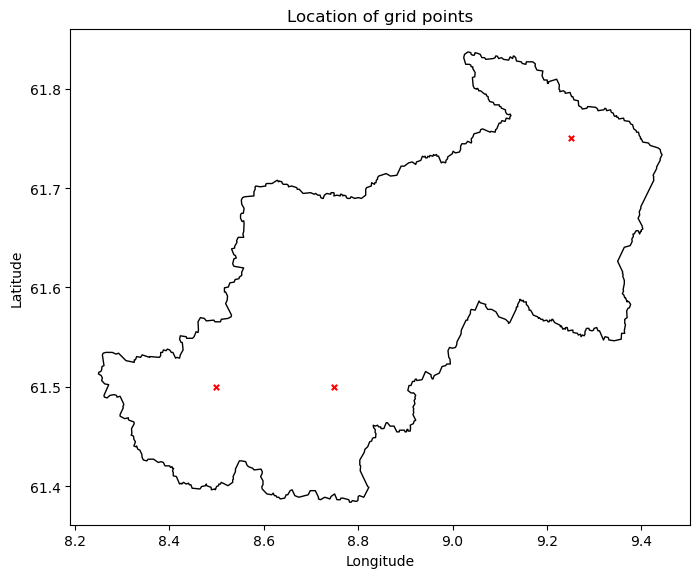

In [ ]:
longs = data_masked['longitude'].values
lats = data_masked['latitude'].values

coords = [(61.5, 8.5), 
          (61.5, 8.75), 
          (61.75, 9.25)]


fig, ax = plt.subplots(figsize=(8, 8))

shape.plot(ax=ax, edgecolor='black', facecolor='none')
ax.scatter([x[1] for x in coords], [x[0] for x in coords], color = 'red', s=15, marker='x')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Location of grid points')
plt.show()